In [1]:
import os
import torch
import torch.nn as nn
import torchvision
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
!pip install torchsummary
from torchsummary import summary
from PIL import Image
import cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt
from glob import glob
import warnings
warnings.filterwarnings('ignore')

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# loading pretrained model
model = models.vgg16(pretrained=True).to(device)
summary(model, (3, 224, 224))

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 98.2MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [5]:
# setup kaggle api
!pip install -q kaggle
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!ls ~/.kaggle
!chmod 600 /root/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json
kaggle.json


In [6]:
# download dataset from kaggle
!kaggle datasets download -d tongpython/cat-and-dog

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
 93% 202M/218M [00:00<00:00, 645MB/s] 
100% 218M/218M [00:00<00:00, 675MB/s]


In [ ]:
# unzip data
!unzip /content/cat-and-dog.zip

In [8]:
# data folders
train_data_path = '/content/training_set/training_set'
test_data_path = '/content/test_set/test_set'

In [9]:
# dataset
class DogAndCatData(Dataset):
  def __init__(self, folder):
    cats = glob(folder + '/cats/*.jpg')
    dogs = glob(folder + '/dogs/*.jpg')
    self.file_paths = cats[:1000] + dogs[:1000]
    self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    from random import shuffle, seed; seed(10)
    shuffle(self.file_paths)
    self.targets = [path.split('/')[-1].startswith('dog') for path in self.file_paths]

  def __len__(self):
    return len(self.file_paths)

  def __getitem__(self, ix):
    f = self.file_paths[ix]
    target = self.targets[ix]
    target = torch.tensor([target])
    img = (cv2.imread(f)[:, :, ::-1]) #bgr to rgb
    img = cv2.resize(img, (224, 224))
    img = torch.tensor(img/225)
    img = img.permute(2, 0, 1)
    img = self.normalize(img)
    return (
        img.float().to(device),
        target.float().to(device)
    )

In [11]:
data = DogAndCatData(train_data_path)

tensor([0.], device='cuda:0')


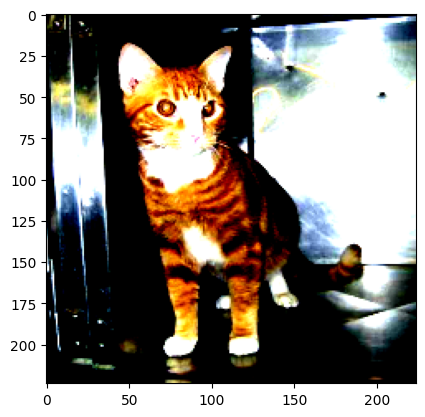

In [12]:
img, label = data[4]
plt.imshow(img.permute(1, 2, 0).cpu())
print(label)

In [13]:
def get_data():
  train_data = DogAndCatData(train_data_path)
  test_data = DogAndCatData(test_data_path)
  train_dl = DataLoader(train_data, batch_size=32, shuffle=True, drop_last=True)
  val_dl = DataLoader(test_data, batch_size=32, shuffle=True, drop_last=True)
  return train_dl, val_dl
train_dl, val_dl = get_data()

In [14]:
def get_model():
  model = models.vgg16(pretrained=True)
  for param in model.parameters():
    # freeze params of vgg16
    param.requires_grad = False
    # replace avgpool
    model.avgpool = nn.AdaptiveAvgPool2d(output_size=(1, 1))
    model.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(512, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 1),
        nn.Sigmoid()
    )
    loss_func = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
  return model.to(device), loss_func, optimizer

model, loss_func, optimizer = get_model()
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [15]:
def train(x, y, model, optimizer, loss_func):
  model.train()
  prediction = model(x)
  batch_loss = loss_func(prediction, y)
  batch_loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  return batch_loss.item()

In [16]:
@torch.no_grad()
def accuracy(x, y, model):
  model.eval()
  prediction = model(x)
  is_correct = (prediction > 0.5) == y
  return is_correct.cpu().numpy().tolist()

In [17]:
# train model
train_losses, train_accuracies = [], []
val_accuracies = []
for epoch in range(5):
  print('epoch: ', epoch+1)
  train_epoch_losses, train_epoch_accuracies = [], []
  val_epoch_accuracies = []
  # train loss
  for ix, batch in enumerate(iter(train_dl)):
    x, y = batch
    batch_loss = train(x, y, model, optimizer , loss_func)
    train_epoch_losses.append(batch_loss)
  train_epoch_loss = np.array(train_epoch_losses).mean()
  # train accuracy
  for ix, batch in enumerate(iter(train_dl)):
    x, y = batch
    is_correct = accuracy(x, y, model)
    train_epoch_accuracies.extend(is_correct)
  train_epoch_accuracy = np.array(train_epoch_accuracies).mean()
  # val accuracy
  for ix, batch in enumerate(iter(val_dl)):
    x, y = batch
    val_is_correct = accuracy(x, y, model)
    val_epoch_accuracies.extend(val_is_correct)
  val_epoch_accuracy = np.array(val_epoch_accuracies).mean()

  # append losses and accuracies
  train_losses.append(train_epoch_loss)
  train_accuracies.append(train_epoch_accuracy)
  val_accuracies.append(val_epoch_accuracy)


epoch:  1
epoch:  2
epoch:  3
epoch:  4
epoch:  5


In [18]:
print('train loss: ', np.array(train_losses).mean())
print('train accuracy: ', np.array(train_accuracies).mean())
print('val accuracy: ', np.array(val_accuracies).mean())

train loss:  0.05183533081250179
train accuracy:  0.9922379032258064
val accuracy:  0.9806451612903226


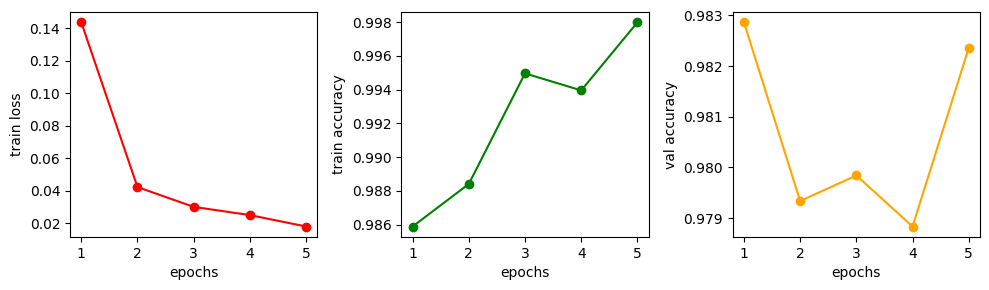

In [19]:
epochs = np.arange(5) + 1
fig, axes = plt.subplots(1,3, figsize=(10, 3))
axes[0].plot(epochs, train_losses, color='red', marker='o', label='train loss')
axes[0].set_ylabel('train loss')
axes[0].set_xlabel('epochs')

axes[1].plot(epochs, train_accuracies, color='green', marker='o', label='train accuracy')
axes[1].set_ylabel('train accuracy')
axes[1].set_xlabel('epochs')

axes[2].plot(epochs, val_accuracies, color='orange', marker='o', label='val accuracy')
axes[2].set_ylabel('val accuracy')
axes[2].set_xlabel('epochs')

plt.tight_layout()
plt.show()